# KPI 3: ExperienceIQ

## Objective

ExperienceIQ measures the overall quality of the guest experience by combining the key dimensions of guest reviews into a single composite indicator.

Unlike ListingIQ, which evaluates the intrinsic characteristics of a listing, ExperienceIQ focuses on how guests perceive and experience their stay. The KPI is constructed using individual review dimensions that collectively contribute to overall guest satisfaction.

Each candidate variable is validated through Exploratory Data Analysis (EDA), Random Forest Feature Importance, and Permutation Importance before determining the final component weights.

## Candidate Variables:
1. review_scores_cleanliness
2. review_scores_checkin
3. review_scores_communication

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

## Validation 1: Cleanliness

The **Review Scores Cleanliness** variable reflects guests' assessment of the cleanliness and hygiene of a listing during their stay.

Cleanliness is one of the most fundamental aspects of the guest experience and is expected to have a strong influence on overall guest satisfaction. This analysis evaluates whether cleanliness is associated with overall guest ratings and whether it should contribute to the ExperienceIQ score.

In [2]:
listings_clean = pd.read_csv(
    "../../../Data/cleaned/Listings_Clean.csv",
    encoding="latin1"
)
listings_clean = pd.read_csv(
    "../../../Data/cleaned/Listings_Clean.csv",
    encoding="latin1"
)


In [3]:
listings_fe = listings_clean.copy()

In [4]:
listings_fe["review_scores_cleanliness"].describe()

count    188047.000000
mean          9.312869
std           1.146072
min           2.000000
25%           9.000000
50%          10.000000
75%          10.000000
max          10.000000
Name: review_scores_cleanliness, dtype: float64

In [5]:
cleanliness_analysis = (
    listings_fe
    .groupby("review_scores_cleanliness")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

cleanliness_analysis

,count,mean,median,std
review_scores_cleanliness,,,,
2.0,1270,31.443307,20.0,19.094461
3.0,79,45.518987,40.0,17.453866
4.0,852,58.030516,60.0,19.554894
5.0,541,64.347505,66.0,12.921893
6.0,3206,72.457268,80.0,17.244427
7.0,3810,80.081365,80.0,9.545249
8.0,17140,87.010152,87.0,9.701407
9.0,52106,92.527713,93.0,5.125715
10.0,109015,97.099262,99.0,5.140477


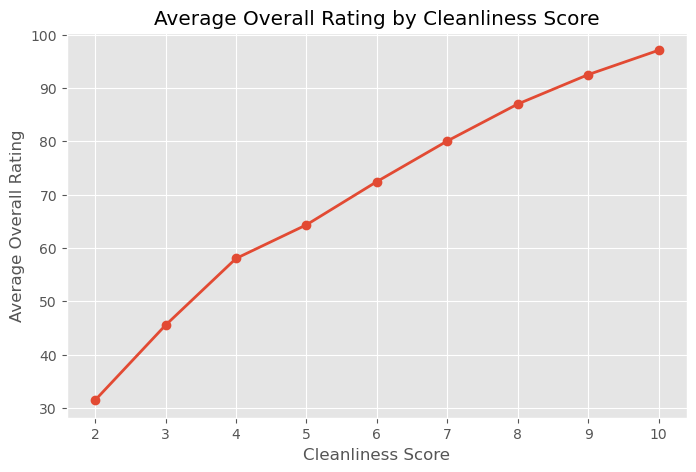

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    cleanliness_analysis.index,
    cleanliness_analysis["mean"],
    marker="o",
    linewidth=2
)

plt.title("Average Overall Rating by Cleanliness Score")
plt.xlabel("Cleanliness Score")
plt.ylabel("Average Overall Rating")

plt.grid(True)
plt.show()

| Metric                             | Assessment      |
| ---------------------------------- | --------------- |
| Business Relevance                 | **High**        |
| Observed Impact                    | **Very Strong** |
| Data Reliability                   | **High**        |
| Improvement Potential              | **High**        |
| Expected Influence on ExperienceIQ | **Very High**   |


## Validation 2: Review Scores Check-in

The **Review Scores Check-in** variable reflects guests' assessment of the ease, convenience, and efficiency of the check-in process.

A smooth and hassle-free check-in creates a positive first impression and contributes significantly to the overall guest experience. This analysis evaluates whether guest-perceived check-in quality is associated with overall guest satisfaction and whether it should be incorporated into the ExperienceIQ framework.

In [7]:
listings_fe["review_scores_checkin"].describe()

count    187941.000000
mean          9.701534
std           0.867434
min           2.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          10.000000
Name: review_scores_checkin, dtype: float64

In [8]:
checkin_analysis = (
    listings_fe
    .groupby("review_scores_checkin")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

checkin_analysis

,count,mean,median,std
review_scores_checkin,,,,
2.0,961,28.010406,20.0,18.010006
3.0,16,41.437500,40.0,17.274138
4.0,327,54.706422,60.0,23.533283
5.0,145,55.537931,53.0,15.148350
6.0,1380,64.785507,60.0,20.823310
7.0,1135,73.469604,73.0,12.553192
8.0,5682,80.912179,80.0,14.777188
9.0,25291,89.376853,90.0,6.828531
10.0,152976,95.484109,97.0,6.674652


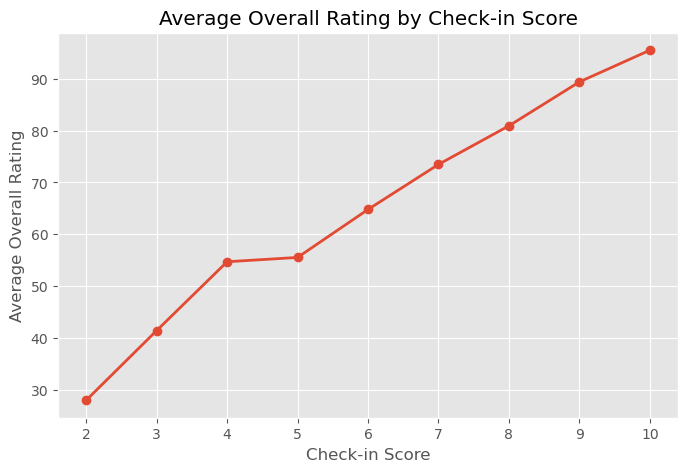

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    checkin_analysis.index,
    checkin_analysis["mean"],
    marker="o",
    linewidth=2
)

plt.title("Average Overall Rating by Check-in Score")
plt.xlabel("Check-in Score")
plt.ylabel("Average Overall Rating")

plt.grid(True)

plt.show()

| Metric                             | Assessment      |
| ---------------------------------- | --------------- |
| Business Relevance                 | **High**        |
| Observed Impact                    | **Very Strong** |
| Data Reliability                   | **High**        |
| Improvement Potential              | **High**        |
| Expected Influence on ExperienceIQ | **Very High**   |


## Validation 3: Review Scores Communication

The **Review Scores Communication** variable represents guests' assessment of the quality, responsiveness, and effectiveness of communication with the host before and during their stay.

Clear and timely communication helps guests resolve issues, receive important information, and feel supported throughout their stay. Consequently, effective host communication is expected to contribute positively to overall guest satisfaction.

This analysis evaluates whether guest-perceived communication quality is associated with overall guest ratings and whether it should be incorporated into the ExperienceIQ framework.

In [10]:
listings_fe["review_scores_communication"].describe()

count    188025.000000
mean          9.698593
std           0.886884
min           2.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          10.000000
Name: review_scores_communication, dtype: float64

In [11]:
communication_analysis = (
    listings_fe
    .groupby("review_scores_communication")["review_scores_rating"]
    .agg(["count", "mean", "median", "std"])
)

communication_analysis

,count,mean,median,std
review_scores_communication,,,,
2.0,1019,27.379784,20.0,16.968248
3.0,22,41.863636,40.0,15.103754
4.0,372,47.690860,40.0,22.878175
5.0,159,54.238994,53.0,14.818932
6.0,1431,63.520615,60.0,19.296928
7.0,1229,72.021155,73.0,11.747113
8.0,5663,80.357231,80.0,13.716385
9.0,24571,88.899231,90.0,6.648738
10.0,153531,95.660297,97.0,6.245452


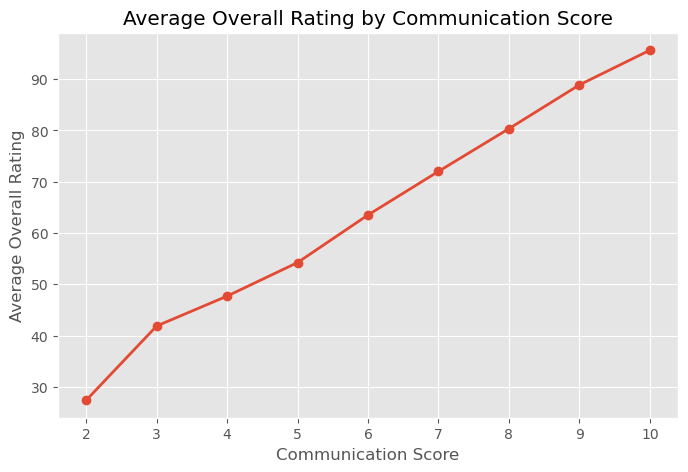

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    communication_analysis.index,
    communication_analysis["mean"],
    marker="o",
    linewidth=2
)

plt.title("Average Overall Rating by Communication Score")
plt.xlabel("Communication Score")
plt.ylabel("Average Overall Rating")

plt.grid(True)

plt.show()

| Metric                             | Assessment      |
| ---------------------------------- | --------------- |
| Business Relevance                 | **High**        |
| Observed Impact                    | **Very Strong** |
| Data Reliability                   | **High**        |
| Improvement Potential              | **High**        |
| Expected Influence on ExperienceIQ | **Very High**   |


| Variable      | Business Relevance | Observed Impact | Data Reliability | Improvement Potential | Expected Influence |
| ------------- | ------------------ | --------------- | ---------------- | --------------------- | ------------------ |
| Cleanliness   | High               | Very Strong     | High             | High                  | Very High          |
| Check-in      | High               | Very Strong     | High             | High                  | Very High          |
| Communication | High               | Very Strong     | High             | High                  | Very High          |


## Random Forest Feature Importance

A Random Forest Regressor is trained to predict the overall guest rating (`review_scores_rating`) using the validated ExperienceIQ variables.

The resulting feature importances provide an estimate of each variable's contribution during model training and serve as one of the inputs for determining the final component weights.

In [13]:
experience_ml = listings_fe[
    [
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_rating"
    ]
].dropna()

In [14]:
features = [
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

X = experience_ml[features]

y = experience_ml["review_scores_rating"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
rf_importance = pd.DataFrame({
    "Variable": features,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Variable,Importance
0,review_scores_cleanliness,0.633081
2,review_scores_communication,0.333992
1,review_scores_checkin,0.032926


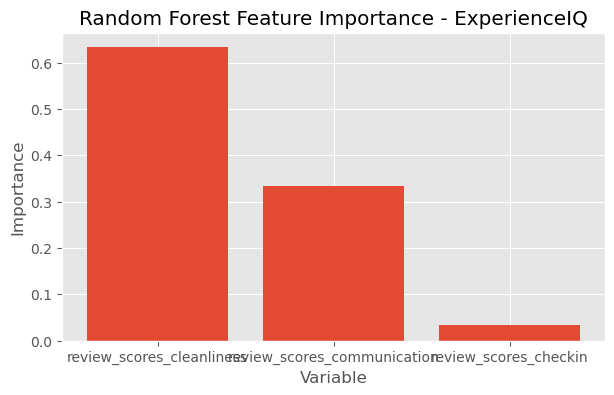

In [17]:
plt.figure(figsize=(7,4))

plt.bar(
    rf_importance["Variable"],
    rf_importance["Importance"]
)

plt.title("Random Forest Feature Importance - ExperienceIQ")
plt.xlabel("Variable")
plt.ylabel("Importance")

plt.show()

In [18]:
perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [19]:
perm_importance = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": perm.importances_mean
})

perm_importance = perm_importance.sort_values(
    "Importance",
    ascending=False
)

perm_importance

,Variable,Importance
0,review_scores_cleanliness,0.460944
2,review_scores_communication,0.201443
1,review_scores_checkin,0.062983


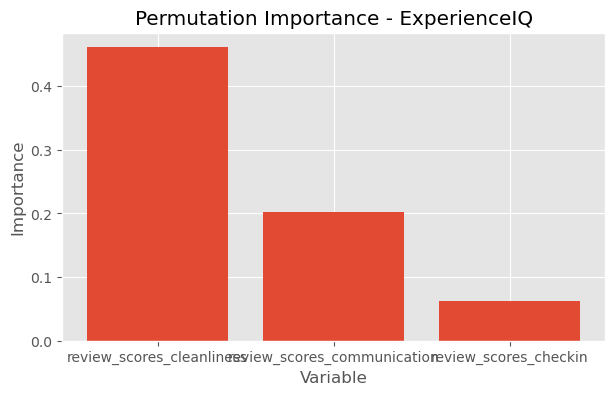

In [20]:
plt.figure(figsize=(7,4))

plt.bar(
    perm_importance["Variable"],
    perm_importance["Importance"]
)

plt.title("Permutation Importance - ExperienceIQ")
plt.xlabel("Variable")
plt.ylabel("Importance")

plt.show()

In [21]:
eda_scores = pd.DataFrame({
    "Variable": [
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication"
    ],
    "EDA_Score": [
        1.0,
        1.0,
        1.0
    ]
})

eda_scores["EDA_Normalized"] = (
    eda_scores["EDA_Score"] /
    eda_scores["EDA_Score"].sum()
)

In [22]:
weights = (
    rf_importance
    .merge(
        perm_importance,
        on="Variable",
        suffixes=("_RF", "_Permutation")
    )
    .merge(
        eda_scores[["Variable", "EDA_Normalized"]],
        on="Variable"
    )
)

weights

,Variable,Importance_RF,Importance_Permutation,EDA_Normalized
0,review_scores_cleanliness,0.633081,0.460944,0.333333
1,review_scores_communication,0.333992,0.201443,0.333333
2,review_scores_checkin,0.032926,0.062983,0.333333


In [23]:
weights["Composite_Score"] = (
    0.30 * weights["Importance_RF"] +
    0.60 * weights["Importance_Permutation"] +
    0.10 * weights["EDA_Normalized"]
)

In [24]:
weights["Final_Weight"] = (
    weights["Composite_Score"] /
    weights["Composite_Score"].sum()
) * 100

weights = weights.sort_values(
    "Final_Weight",
    ascending=False
)

weights

,Variable,Importance_RF,Importance_Permutation,EDA_Normalized,Composite_Score,Final_Weight
0,review_scores_cleanliness,0.633081,0.460944,0.333333,0.499824,59.843283
1,review_scores_communication,0.333992,0.201443,0.333333,0.254397,30.458590
2,review_scores_checkin,0.032926,0.062983,0.333333,0.081001,9.698127


In [25]:
corr = experience_ml[
    [
        "review_scores_cleanliness",
        "review_scores_checkin",
        "review_scores_communication",
        "review_scores_rating"
    ]
].corr()

corr

,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_rating
review_scores_cleanliness,1.000000,0.525331,0.540796,0.740610
review_scores_checkin,0.525331,1.000000,0.735968,0.661411
review_scores_communication,0.540796,0.735968,1.000000,0.708608
review_scores_rating,0.740610,0.661411,0.708608,1.000000


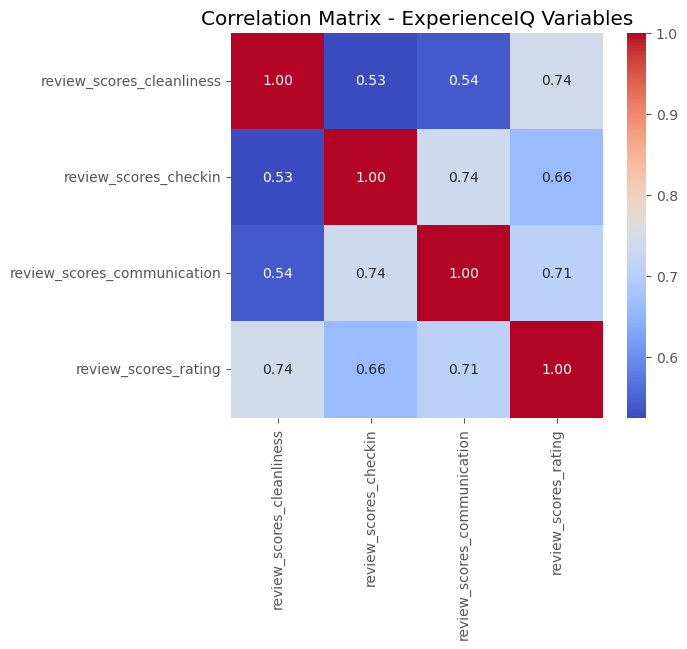

In [26]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - ExperienceIQ Variables")

plt.show()

In [27]:
min_clean = listings_fe["review_scores_cleanliness"].min()
max_clean = listings_fe["review_scores_cleanliness"].max()

listings_fe["cleanliness_score"] = (
    (listings_fe["review_scores_cleanliness"] - min_clean)
    /
    (max_clean - min_clean)
)

In [28]:
min_check = listings_fe["review_scores_checkin"].min()
max_check = listings_fe["review_scores_checkin"].max()

listings_fe["checkin_score"] = (
    (listings_fe["review_scores_checkin"] - min_check)
    /
    (max_check - min_check)
)

In [29]:
min_comm = listings_fe["review_scores_communication"].min()
max_comm = listings_fe["review_scores_communication"].max()

listings_fe["communication_score"] = (
    (listings_fe["review_scores_communication"] - min_comm)
    /
    (max_comm - min_comm)
)

In [30]:
listings_fe["ExperienceIQ"] = (
    0.5984 * listings_fe["cleanliness_score"] +
    0.3046 * listings_fe["communication_score"] +
    0.0970 * listings_fe["checkin_score"]
) * 100

In [31]:
listings_fe["ExperienceIQ"].describe()

count    187920.000000
mean         93.356688
std          11.473039
min           0.000000
25%          91.307500
50%         100.000000
75%         100.000000
max         100.000000
Name: ExperienceIQ, dtype: float64

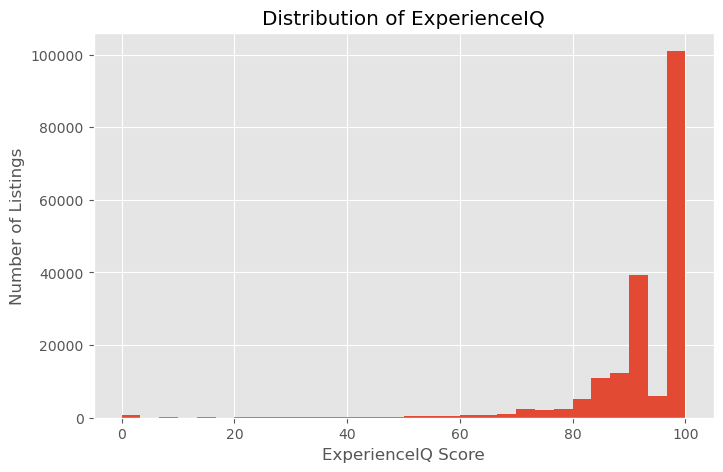

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    listings_fe["ExperienceIQ"],
    bins=30
)

plt.title("Distribution of ExperienceIQ")
plt.xlabel("ExperienceIQ Score")
plt.ylabel("Number of Listings")

plt.show()

In [33]:
bins = [0, 20, 40, 60, 80, 100]

labels = [
    "0-20",
    "21-40",
    "41-60",
    "61-80",
    "81-100"
]

listings_fe["ExperienceIQ_Group"] = pd.cut(
    listings_fe["ExperienceIQ"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [34]:
experience_validation = (
    listings_fe
    .groupby("ExperienceIQ_Group")["review_scores_rating"]
    .agg(["count","mean","median","std"])
)

experience_validation

,count,mean,median,std
ExperienceIQ_Group,,,,
0-20,896,23.614955,20.0,10.833847
21-40,693,42.675325,40.0,18.159137
41-60,2144,61.725746,60.0,15.949886
61-80,9431,79.043898,80.0,11.825596
81-100,174728,95.137408,97.0,5.829514


In [35]:
listings_fe.to_csv("ExperienceIQ_Output.csv", index=False)

In [36]:
listings_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279599 entries, 0 to 279598
Data columns (total 37 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   listing_id                   279599 non-null  int64   
 1   name                         279424 non-null  object  
 2   host_id                      279599 non-null  int64   
 3   host_since                   279434 non-null  object  
 4   host_location                278759 non-null  object  
 5   host_response_time           150898 non-null  object  
 6   host_response_rate           150898 non-null  float64 
 7   host_acceptance_rate         166577 non-null  float64 
 8   host_is_superhost            279434 non-null  object  
 9   host_total_listings_count    279434 non-null  float64 
 10  host_has_profile_pic         279434 non-null  object  
 11  host_identity_verified       279434 non-null  object  
 12  neighbourhood                279599 non-null

In [37]:
component_cols = [
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication"
]

for col in component_cols:
    missing_pct = listings_fe[col].isna().mean() * 100
    print(f"{col}: {missing_pct:.1f}% missing")

review_scores_cleanliness: 32.7% missing
review_scores_checkin: 32.8% missing
review_scores_communication: 32.8% missing
